# Cohort & Retention Deep Dive
### Customer Lifecycle Analytics on Brazilian E-Commerce Data

**Author:** Tobi Bolu
**Tools:** Python, Pandas, Plotly, Tableau Public
**Dataset:** [Olist Brazilian E-Commerce (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

## Overview

I'm building four analytical layers on top of the Olist e-commerce dataset: **cohort-based retention analysis**, **RFM segmentation**, **customer lifetime value estimation**, and **churn risk flagging**. Each layer produces a Tableau-ready CSV export so the findings can be explored interactively in a published Tableau Public dashboard.

This complements my Project A work (SQL analytics on the same dataset) by shifting from transaction-level queries to customer-level behavioral modeling.

---

## Step 1: Setup & Data Loading

I'm loading the Olist dataset and preparing the base tables for customer-level analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import kagglehub

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# Downloading dataset from Kaggle (cached after first run)
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print('Dataset downloaded to:', path)


/Users/tobibolu/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Dataset downloaded to: /Users/tobibolu/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


## Step 2: Build Customer Transaction Table

I'm merging orders, items, payments, and customers into a single customer-transaction view.

In [2]:
# Loading the core tables
import os
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))

print(f'Orders: {len(orders):,} rows')
print(f'Items: {len(items):,} rows')
print(f'Payments: {len(payments):,} rows')
print(f'Customers: {len(customers):,} rows')

Orders: 99,441 rows
Items: 112,650 rows
Payments: 103,886 rows
Customers: 99,441 rows


In [3]:
# Filtering to delivered orders only and parsing dates
orders = orders[orders['order_status'] == 'delivered'].copy()
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Aggregating payment per order
order_payments = payments.groupby('order_id')['payment_value'].sum().reset_index()

# Aggregating review score per order
order_reviews = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Merging everything into one table
df = orders.merge(customers[['customer_id', 'customer_unique_id', 'customer_state']], on='customer_id')
df = df.merge(order_payments, on='order_id', how='left')
df = df.merge(order_reviews, on='order_id', how='left')

# Getting product category for each order (using the first item)
first_item = items.drop_duplicates('order_id')[['order_id', 'product_id']]
first_item = first_item.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
df = df.merge(first_item[['order_id', 'product_category_name']], on='order_id', how='left')

print(f'Merged dataset: {len(df):,} delivered orders')
print(f'Unique customers: {df["customer_unique_id"].nunique():,}')
print(f'Date range: {df["order_purchase_timestamp"].min().date()} to {df["order_purchase_timestamp"].max().date()}')

Merged dataset: 96,478 delivered orders
Unique customers: 93,358
Date range: 2016-09-15 to 2018-08-29


## Step 3: Cohort Retention Analysis

I'm assigning each customer to their acquisition cohort (first purchase month) and tracking repurchase behavior over subsequent months.

In [4]:
# Assigning each customer to their acquisition cohort
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

first_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'first_purchase_date']
first_purchase['cohort'] = first_purchase['first_purchase_date'].dt.to_period('M')

df = df.merge(first_purchase, on='customer_unique_id')

# Calculating cohort period (months since first purchase)
df['cohort_period'] = (
    (df['order_purchase_timestamp'].dt.year - df['first_purchase_date'].dt.year) * 12 +
    (df['order_purchase_timestamp'].dt.month - df['first_purchase_date'].dt.month)
)

print(f'Cohort range: {first_purchase["cohort"].min()} to {first_purchase["cohort"].max()}')
print(f'Max cohort period: {df["cohort_period"].max()} months')

Cohort range: 2016-09 to 2018-08
Max cohort period: 20 months


In [5]:
# Building the cohort retention matrix
cohort_data = df.groupby(['cohort', 'cohort_period'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort', 'cohort_period', 'customers']

# Pivoting to matrix form
cohort_matrix = cohort_data.pivot(index='cohort', columns='cohort_period', values='customers')

# Converting to retention percentages
cohort_sizes = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0) * 100

print('Cohort sizes (customers acquired per month):')
print(cohort_sizes.to_string())
print(f'\nRetention matrix shape: {retention_matrix.shape}')

Cohort sizes (customers acquired per month):
cohort
2016-09       1.0
2016-10     262.0
2016-12       1.0
2017-01     717.0
2017-02    1628.0
2017-03    2503.0
2017-04    2256.0
2017-05    3451.0
2017-06    3037.0
2017-07    3752.0
2017-08    4057.0
2017-09    4004.0
2017-10    4328.0
2017-11    7060.0
2017-12    5338.0
2018-01    6842.0
2018-02    6288.0
2018-03    6774.0
2018-04    6582.0
2018-05    6506.0
2018-06    5878.0
2018-07    5949.0
2018-08    6144.0
Freq: M

Retention matrix shape: (23, 20)


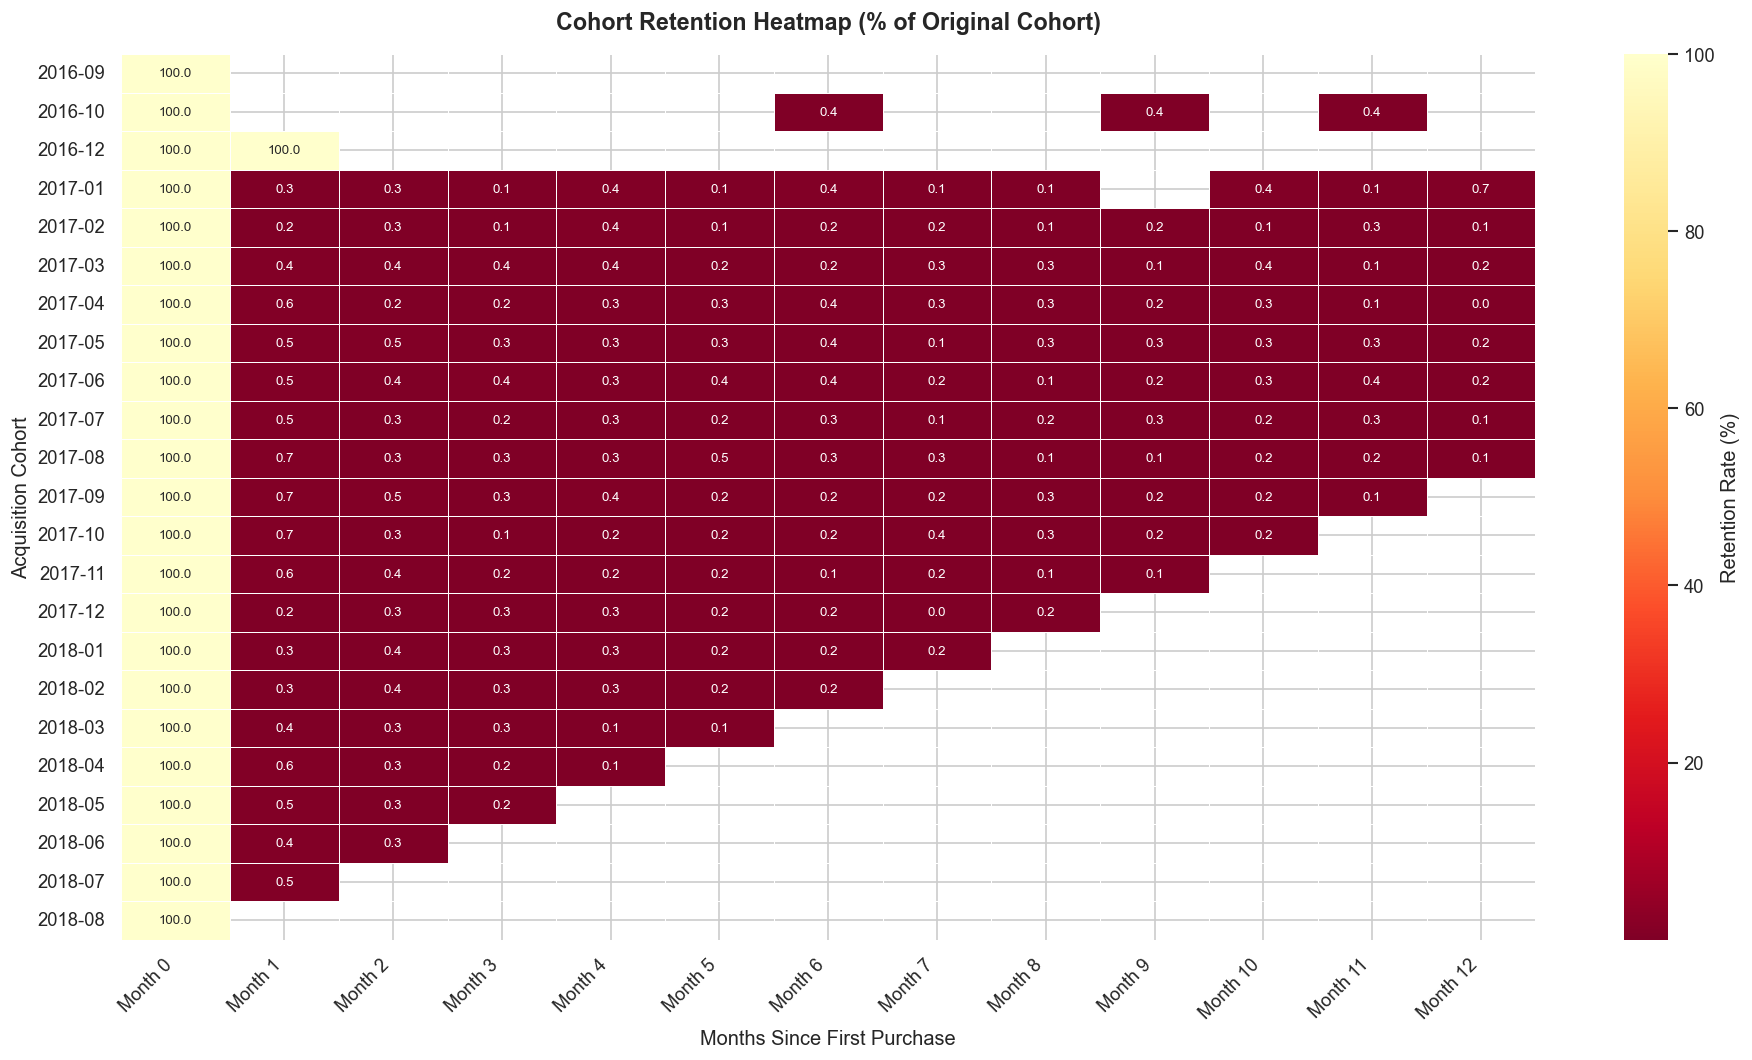

In [6]:
# Visualizing the retention heatmap
ret_display = retention_matrix.iloc[:, :13].copy()
ret_display.index = ret_display.index.astype(str)
ret_display.columns = [f'Month {i}' for i in ret_display.columns]

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(ret_display, annot=True, fmt='.1f', cmap='YlOrRd_r',
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Retention Rate (%)'},
            annot_kws={'size': 8})
ax.set_title('Cohort Retention Heatmap (% of Original Cohort)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Acquisition Cohort')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


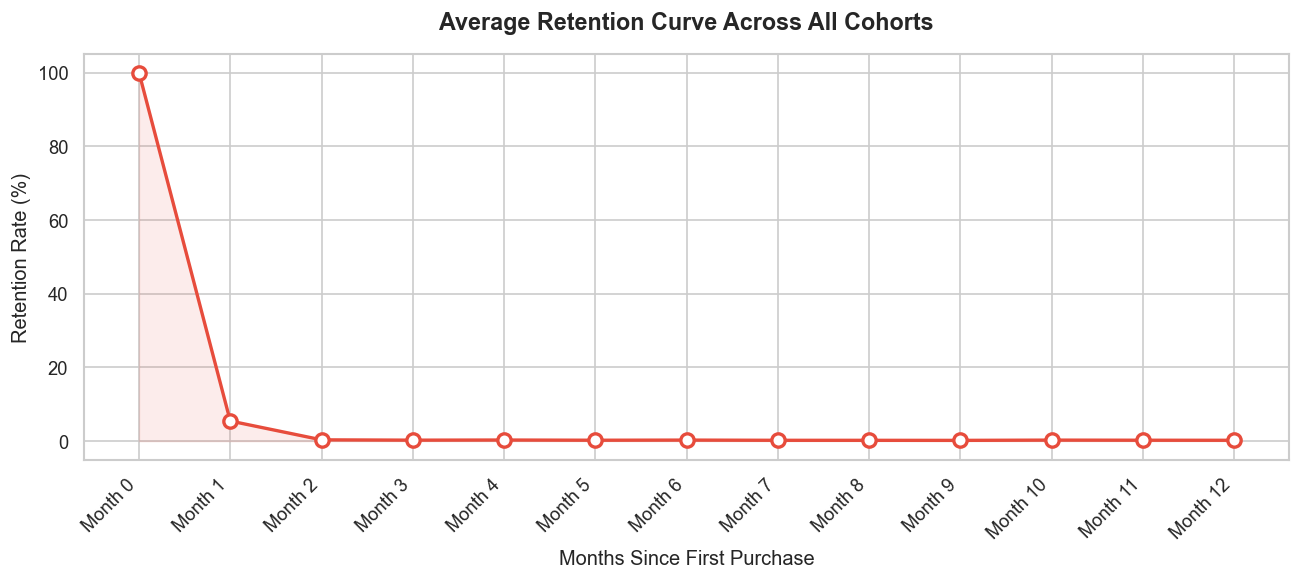

In [7]:
# Plotting average retention curve across all cohorts
avg_retention = retention_matrix.mean()
periods_with_data = avg_retention[avg_retention.notna()].index[:13]
y_vals = [avg_retention[p] for p in periods_with_data]
x_labels = [f'Month {i}' for i in periods_with_data]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_labels, y_vals, marker='o', linewidth=2, markersize=8,
        color='#e74c3c', markerfacecolor='white', markeredgewidth=2)
ax.fill_between(range(len(x_labels)), y_vals, alpha=0.1, color='#e74c3c')
ax.set_xticks(range(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_title('Average Retention Curve Across All Cohorts',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate (%)')
plt.tight_layout()
plt.show()


## Step 4: RFM Segmentation

I'm scoring each customer on Recency, Frequency, and Monetary value, then assigning behavioral segments.

In [8]:
# Calculating RFM metrics per customer
snapshot_date = df['order_purchase_timestamp'].max() + timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'payment_value': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

print(f'RFM table: {len(rfm):,} customers')
print(f'\nRecency (days since last purchase):')
print(f'  Mean: {rfm["recency"].mean():.0f}, Median: {rfm["recency"].median():.0f}')
print(f'\nFrequency (number of orders):')
print(f'  Mean: {rfm["frequency"].mean():.2f}, Max: {rfm["frequency"].max()}')
print(f'\nMonetary (total spend R\$):')
print(f'  Mean: R\${rfm["monetary"].mean():.2f}, Median: R\${rfm["monetary"].median():.2f}')

RFM table: 93,358 customers

Recency (days since last purchase):
  Mean: 238, Median: 219

Frequency (number of orders):
  Mean: 1.03, Max: 15

Monetary (total spend R\$):
  Mean: R\$165.20, Median: R\$107.78


In [9]:
# Scoring RFM on 1-5 scale using quintiles
# For recency, lower is better (more recent), so we reverse the labels
rfm['r_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# For frequency, most customers have 1 order, so I'm using rank-based scoring
rfm['f_score'] = pd.cut(rfm['frequency'],
    bins=[0, 1, 2, 3, 5, 100],
    labels=[1, 2, 3, 4, 5]).astype(int)

rfm['m_score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Creating composite RFM score
rfm['rfm_score'] = rfm['r_score'] * 100 + rfm['f_score'] * 10 + rfm['m_score']

# Assigning customer segments based on RFM patterns
def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 1:
        return 'Lost'
    elif r == 3 and f <= 1:
        return 'About to Sleep'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

print('Customer Segment Distribution:')
print(rfm['segment'].value_counts().to_string())

Customer Segment Distribution:
segment
Recent Customers       36299
Lost                   36228
About to Sleep         18105
Loyal Customers         1590
Cant Lose Them           841
Champions                122
Need Attention            78
At Risk                   69
Potential Loyalists       26


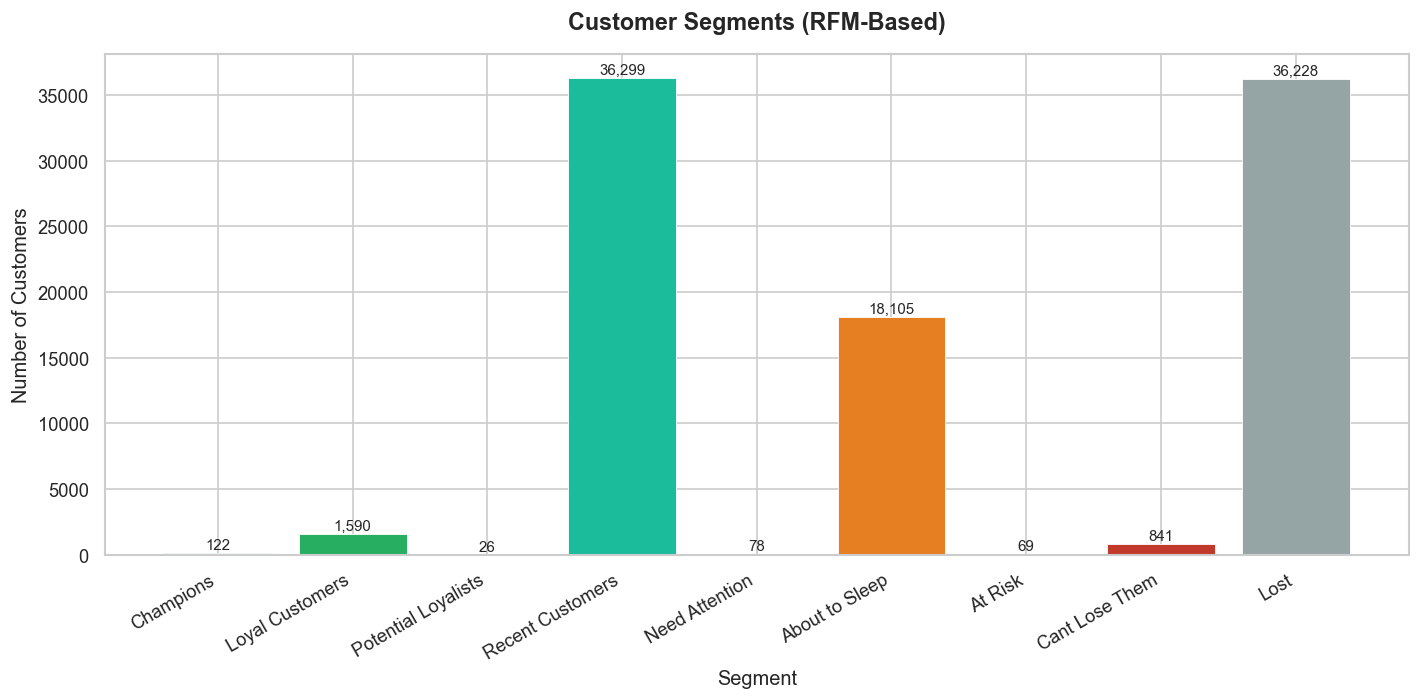

In [10]:
# Visualizing RFM segments
seg_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'Recent Customers',
             'Need Attention', 'About to Sleep', 'At Risk', 'Cant Lose Them', 'Lost']
seg_colors = {
    'Champions': '#2ecc71', 'Loyal Customers': '#27ae60', 'Potential Loyalists': '#3498db',
    'Recent Customers': '#1abc9c', 'Need Attention': '#f39c12', 'About to Sleep': '#e67e22',
    'At Risk': '#e74c3c', 'Cant Lose Them': '#c0392b', 'Lost': '#95a5a6'
}
seg_counts = rfm['segment'].value_counts()
seg_counts = seg_counts.reindex([s for s in seg_order if s in seg_counts.index])

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [seg_colors.get(s, '#3498db') for s in seg_counts.index]
bars = ax.bar(seg_counts.index, seg_counts.values, color=bar_colors,
              edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Customer Segments (RFM-Based)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [11]:
# RFM segment summary: avg recency, frequency, monetary per segment
seg_summary = rfm.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_unique_id': 'count'
}).round(2)
seg_summary.columns = ['avg_recency_days', 'avg_frequency', 'avg_monetary_brl', 'customer_count']
seg_summary = seg_summary.sort_values('avg_monetary_brl', ascending=False)

print('Segment Summary:')
print(seg_summary.to_string())

Segment Summary:
                     avg_recency_days  avg_frequency  avg_monetary_brl  customer_count
segment                                                                               
Champions                       90.01           3.52            553.97             122
At Risk                        393.12           3.14            425.08              69
Loyal Customers                136.03           2.03            315.06            1590
Cant Lose Them                 379.32           2.00            302.06             841
Recent Customers                90.61           1.00            164.14           36299
Lost                           395.35           1.00            161.89           36228
About to Sleep                 220.46           1.00            151.34           18105
Potential Loyalists            212.19           2.00             72.82              26
Need Attention                 405.18           2.00             69.91              78


## Step 5: Customer Lifetime Value Estimation

I'm estimating 12-month LTV by segment and geography using historical purchase patterns.

In [12]:
# Calculating customer-level metrics for LTV
customer_stats = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': ['min', 'max'],
    'order_id': 'nunique',
    'payment_value': 'sum',
    'customer_state': 'first',
    'review_score': 'mean'
}).reset_index()

customer_stats.columns = ['customer_unique_id', 'first_purchase', 'last_purchase',
                           'order_count', 'total_revenue', 'state', 'avg_review']

customer_stats['lifespan_days'] = (customer_stats['last_purchase'] - customer_stats['first_purchase']).dt.days
customer_stats['avg_order_value'] = customer_stats['total_revenue'] / customer_stats['order_count']

# Estimating annualized revenue (12-month LTV proxy)
# For customers with >0 lifespan, annualize their spending
# For single-purchase customers, use their single order value as the base
customer_stats['ltv_12m'] = np.where(
    customer_stats['lifespan_days'] > 30,
    customer_stats['total_revenue'] / customer_stats['lifespan_days'] * 365,
    customer_stats['total_revenue']  # Single-purchase: use actual spend
)

print(f'Customer stats: {len(customer_stats):,} customers')
print(f'\nLTV Distribution:')
print(f'  Mean: R\${customer_stats["ltv_12m"].mean():.2f}')
print(f'  Median: R\${customer_stats["ltv_12m"].median():.2f}')
print(f'  P90: R\${customer_stats["ltv_12m"].quantile(0.9):.2f}')
print(f'  P99: R\${customer_stats["ltv_12m"].quantile(0.99):.2f}')

Customer stats: 93,358 customers

LTV Distribution:
  Mean: R\$177.95
  Median: R\$108.00
  P90: R\$330.28
  P99: R\$1351.42


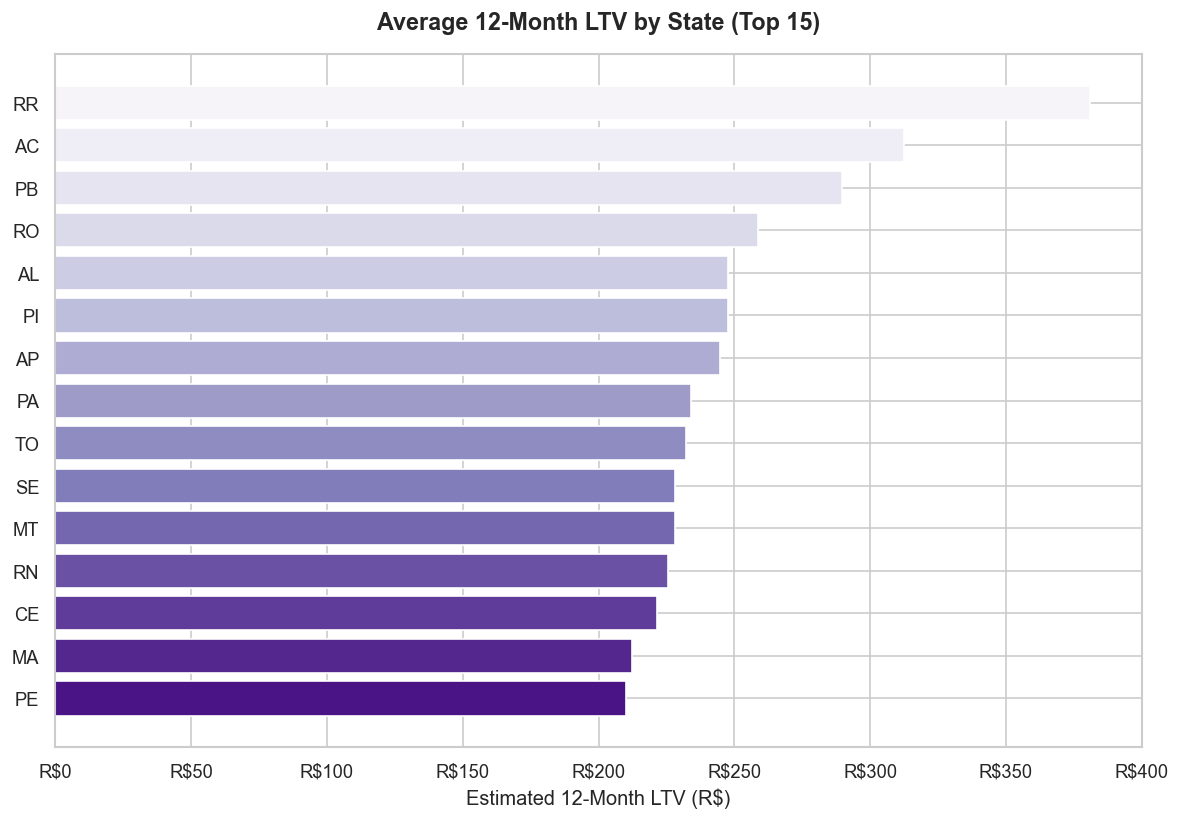

In [13]:
# LTV by state (top 15)
ltv_by_state = customer_stats.groupby('state').agg({
    'ltv_12m': 'mean',
    'customer_unique_id': 'count',
    'total_revenue': 'sum'
}).reset_index()
ltv_by_state.columns = ['state', 'avg_ltv', 'customer_count', 'total_revenue']
ltv_by_state = ltv_by_state.sort_values('avg_ltv', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('Purples_r', len(ltv_by_state))
ax.barh(ltv_by_state['state'][::-1], ltv_by_state['avg_ltv'][::-1], color=colors)
ax.set_title('Average 12-Month LTV by State (Top 15)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel(r'Estimated 12-Month LTV (R\$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
plt.tight_layout()
plt.show()


In [14]:
# LTV by RFM segment
customer_with_rfm = customer_stats.merge(
    rfm[['customer_unique_id', 'segment', 'r_score', 'f_score', 'm_score', 'rfm_score']],
    on='customer_unique_id'
)

ltv_by_segment = customer_with_rfm.groupby('segment').agg({
    'ltv_12m': 'mean',
    'customer_unique_id': 'count',
    'avg_order_value': 'mean',
    'order_count': 'mean'
}).round(2).sort_values('ltv_12m', ascending=False)

ltv_by_segment.columns = ['avg_ltv_12m', 'customer_count', 'avg_order_value', 'avg_orders']

print('LTV by RFM Segment:')
print(ltv_by_segment.to_string())

LTV by RFM Segment:
                     avg_ltv_12m  customer_count  avg_order_value  avg_orders
segment                                                                      
At Risk                  1492.02              69           137.24        3.14
Champions                1182.79             122           157.98        3.52
Loyal Customers           751.59            1590           155.09        2.03
Cant Lose Them            693.60             841           151.03        2.00
Recent Customers          164.38           36299           164.07        1.00
Lost                      161.89           36228           161.89        1.00
Need Attention            154.92              78            34.96        2.00
About to Sleep            151.34           18105           151.34        1.00
Potential Loyalists       137.59              26            36.41        2.00


## Step 6: Churn Risk Flags

I'm flagging customers based on inactivity patterns and purchase behavior to identify churn risk.

In [15]:
# Defining churn risk based on recency and purchase patterns
# Using the dataset's natural rhythm: median gap between repeat purchases
repeat_customers = customer_stats[customer_stats['order_count'] > 1]
if len(repeat_customers) > 0:
    median_gap = repeat_customers['lifespan_days'].median()
    print(f'Median gap between first and last purchase (repeat customers): {median_gap:.0f} days')
else:
    median_gap = 60

# Churn risk tiers based on recency
max_date = df['order_purchase_timestamp'].max()
customer_stats['days_since_last'] = (max_date - customer_stats['last_purchase']).dt.days

def assign_churn_risk(row):
    days = row['days_since_last']
    orders = row['order_count']
    if days <= 90:
        return 'Active'
    elif days <= 180:
        return 'Warm'
    elif days <= 365:
        if orders > 1:
            return 'At Risk (Repeat)'
        else:
            return 'Cooling'
    else:
        if orders > 1:
            return 'Churned (Was Repeat)'
        else:
            return 'Churned (One-time)'

customer_stats['churn_risk'] = customer_stats.apply(assign_churn_risk, axis=1)

print('\nChurn Risk Distribution:')
churn_dist = customer_stats['churn_risk'].value_counts()
for risk, count in churn_dist.items():
    print(f'  {risk}: {count:,} ({count/len(customer_stats)*100:.1f}%)')

Median gap between first and last purchase (repeat customers): 34 days

Churn Risk Distribution:
  Cooling: 33,347 (35.7%)
  Churned (One-time): 20,099 (21.5%)
  Warm: 19,762 (21.2%)
  Active: 18,590 (19.9%)
  At Risk (Repeat): 1,068 (1.1%)
  Churned (Was Repeat): 492 (0.5%)


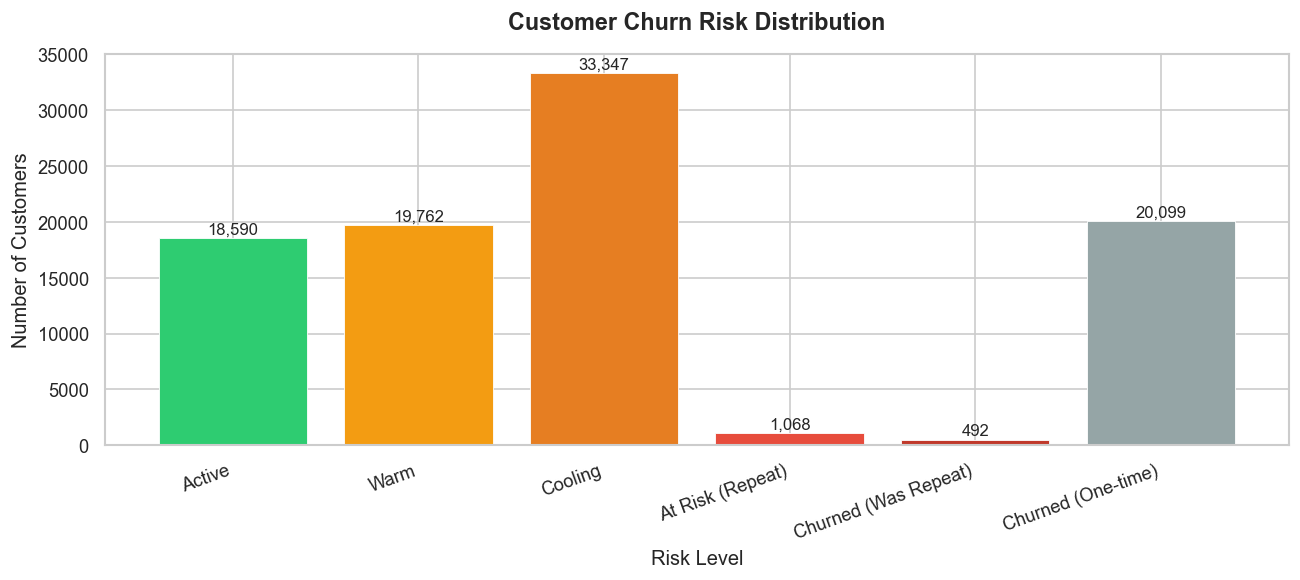

In [16]:
# Churn risk visualization
risk_order = ['Active', 'Warm', 'Cooling', 'At Risk (Repeat)', 'Churned (Was Repeat)', 'Churned (One-time)']
risk_colors_map = {
    'Active': '#2ecc71', 'Warm': '#f39c12', 'Cooling': '#e67e22',
    'At Risk (Repeat)': '#e74c3c', 'Churned (Was Repeat)': '#c0392b', 'Churned (One-time)': '#95a5a6'
}
risk_counts = customer_stats['churn_risk'].value_counts().reindex(
    [r for r in risk_order if r in customer_stats['churn_risk'].values]
).fillna(0)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [risk_colors_map.get(r, '#3498db') for r in risk_counts.index]
bars = ax.bar(risk_counts.index, risk_counts.values, color=bar_colors,
              edgecolor='white', linewidth=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Customer Churn Risk Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


In [17]:
# Churn risk by state — which states have the highest active vs churned ratios?
state_risk = pd.crosstab(customer_stats['state'], customer_stats['churn_risk'], normalize='index') * 100

# Calculating a composite risk score per state (% in at-risk + churned categories)
risk_cols = [c for c in state_risk.columns if 'Churn' in c or 'Risk' in c]
state_risk['risk_pct'] = state_risk[risk_cols].sum(axis=1) if risk_cols else 0
state_risk = state_risk.sort_values('risk_pct', ascending=False)

print('Top 10 states by churn risk %:')
for state in state_risk.head(10).index:
    print(f'  {state}: {state_risk.loc[state, "risk_pct"]:.1f}% at-risk/churned')

Top 10 states by churn risk %:
  AC: 40.8% at-risk/churned
  RR: 32.5% at-risk/churned
  RO: 30.0% at-risk/churned
  AM: 30.0% at-risk/churned
  SE: 29.7% at-risk/churned
  PA: 28.4% at-risk/churned
  AL: 28.2% at-risk/churned
  MA: 26.5% at-risk/churned
  RS: 26.1% at-risk/churned
  PI: 25.9% at-risk/churned


## Step 7: Export Tableau-Ready CSVs

I'm exporting four CSV files for the Tableau Public dashboard.

In [18]:
# Export 1: Cohort retention data (long format for Tableau)
cohort_export = cohort_data.copy()
cohort_export['cohort'] = cohort_export['cohort'].astype(str)

# Adding cohort size and retention rate
cohort_sizes_dict = cohort_sizes.to_dict()
cohort_export['cohort_size'] = cohort_export['cohort'].map(
    {str(k): v for k, v in cohort_sizes_dict.items()}
)
cohort_export['retention_rate'] = (cohort_export['customers'] / cohort_export['cohort_size'] * 100).round(2)

cohort_export.to_csv('./tableau_cohort_retention.csv', index=False)
print(f'Exported cohort retention: {len(cohort_export):,} rows')
print(f'Columns: {list(cohort_export.columns)}')

Exported cohort retention: 219 rows
Columns: ['cohort', 'cohort_period', 'customers', 'cohort_size', 'retention_rate']


In [19]:
# Export 2: RFM customer-level data
rfm_export = rfm.merge(
    customer_stats[['customer_unique_id', 'state', 'total_revenue', 'order_count',
                     'avg_order_value', 'lifespan_days', 'days_since_last', 'avg_review']],
    on='customer_unique_id'
)

# Adding cohort info
rfm_export = rfm_export.merge(
    first_purchase[['customer_unique_id', 'cohort']],
    on='customer_unique_id'
)
rfm_export['cohort'] = rfm_export['cohort'].astype(str)

rfm_export.to_csv('./tableau_rfm_customers.csv', index=False)
print(f'Exported RFM customers: {len(rfm_export):,} rows')
print(f'Columns: {list(rfm_export.columns)}')

Exported RFM customers: 93,358 rows
Columns: ['customer_unique_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment', 'state', 'total_revenue', 'order_count', 'avg_order_value', 'lifespan_days', 'days_since_last', 'avg_review', 'cohort']


In [20]:
# Export 3: LTV by segment and state
ltv_export = customer_with_rfm[['customer_unique_id', 'state', 'segment', 'ltv_12m',
                                 'total_revenue', 'order_count', 'avg_order_value',
                                 'lifespan_days', 'avg_review']].copy()

# Adding cohort
ltv_export = ltv_export.merge(
    first_purchase[['customer_unique_id', 'cohort']],
    on='customer_unique_id'
)
ltv_export['cohort'] = ltv_export['cohort'].astype(str)

ltv_export.to_csv('./tableau_ltv_data.csv', index=False)
print(f'Exported LTV data: {len(ltv_export):,} rows')
print(f'Columns: {list(ltv_export.columns)}')

Exported LTV data: 93,358 rows
Columns: ['customer_unique_id', 'state', 'segment', 'ltv_12m', 'total_revenue', 'order_count', 'avg_order_value', 'lifespan_days', 'avg_review', 'cohort']


In [21]:
# Export 4: Churn risk customer-level data
churn_export = customer_stats[['customer_unique_id', 'state', 'order_count',
                                'total_revenue', 'avg_order_value', 'lifespan_days',
                                'days_since_last', 'avg_review', 'churn_risk']].copy()

# Adding RFM segment
churn_export = churn_export.merge(
    rfm[['customer_unique_id', 'segment', 'r_score', 'f_score', 'm_score']],
    on='customer_unique_id'
)

# Adding cohort
churn_export = churn_export.merge(
    first_purchase[['customer_unique_id', 'cohort']],
    on='customer_unique_id'
)
churn_export['cohort'] = churn_export['cohort'].astype(str)

churn_export.to_csv('./tableau_churn_risk.csv', index=False)
print(f'Exported churn risk: {len(churn_export):,} rows')
print(f'Columns: {list(churn_export.columns)}')

Exported churn risk: 93,358 rows
Columns: ['customer_unique_id', 'state', 'order_count', 'total_revenue', 'avg_order_value', 'lifespan_days', 'days_since_last', 'avg_review', 'churn_risk', 'segment', 'r_score', 'f_score', 'm_score', 'cohort']


## Step 8: Summary Statistics

I'm pulling together the key numbers across all four analyses.

In [22]:
print('=' * 70)
print('PROJECT C: COHORT & RETENTION ANALYSIS SUMMARY')
print('=' * 70)

print(f'\n1. COHORT RETENTION')
print(f'   Total cohorts: {retention_matrix.shape[0]}')
print(f'   Avg Month 1 retention: {retention_matrix[1].mean():.2f}%')
print(f'   Avg Month 3 retention: {retention_matrix[3].mean():.2f}%' if 3 in retention_matrix.columns else '   Month 3: N/A')

print(f'\n2. RFM SEGMENTATION')
print(f'   Total customers scored: {len(rfm):,}')
champions = (rfm['segment'] == 'Champions').sum()
lost = (rfm['segment'] == 'Lost').sum()
print(f'   Champions: {champions:,} ({champions/len(rfm)*100:.1f}%)')
print(f'   Lost: {lost:,} ({lost/len(rfm)*100:.1f}%)')

print(f'\n3. LIFETIME VALUE')
print(f'   Mean 12-month LTV: R\${customer_stats["ltv_12m"].mean():.2f}')
print(f'   Top segment LTV: {ltv_by_segment.index[0]} at R\${ltv_by_segment["avg_ltv_12m"].iloc[0]:.2f}')

print(f'\n4. CHURN RISK')
active = (customer_stats['churn_risk'] == 'Active').sum()
at_risk_repeat = (customer_stats['churn_risk'] == 'At Risk (Repeat)').sum()
print(f'   Active customers: {active:,} ({active/len(customer_stats)*100:.1f}%)')
print(f'   At Risk (Repeat): {at_risk_repeat:,}')

print(f'\n5. TABLEAU EXPORTS')
print(f'   tableau_cohort_retention.csv')
print(f'   tableau_rfm_customers.csv')
print(f'   tableau_ltv_data.csv')
print(f'   tableau_churn_risk.csv')

PROJECT C: COHORT & RETENTION ANALYSIS SUMMARY

1. COHORT RETENTION
   Total cohorts: 23
   Avg Month 1 retention: 5.45%
   Avg Month 3 retention: 0.25%

2. RFM SEGMENTATION
   Total customers scored: 93,358
   Champions: 122 (0.1%)
   Lost: 36,228 (38.8%)

3. LIFETIME VALUE
   Mean 12-month LTV: R\$177.95
   Top segment LTV: At Risk at R\$1492.02

4. CHURN RISK
   Active customers: 18,590 (19.9%)
   At Risk (Repeat): 1,068

5. TABLEAU EXPORTS
   tableau_cohort_retention.csv
   tableau_rfm_customers.csv
   tableau_ltv_data.csv
   tableau_churn_risk.csv


### What I Took Away from the Cohort & Retention Analysis

The retention picture confirms what the SQL analysis in Project A surfaced: this is overwhelmingly a one-and-done marketplace. Average Month 1 retention hovers in the low single digits, and by Month 3 it's essentially flat. The cohort heatmap shows this isn't a seasonal effect or a problem with specific acquisition periods. It's structural: Olist operates as a marketplace aggregator where most customers don't even realize they purchased through Olist, so there's no brand-level loyalty mechanism driving repeat behavior.

The RFM segmentation quantifies the customer base structure more precisely. The vast majority of customers land in the "Lost" or "About to Sleep" segments because they made one purchase months ago and never returned. The small "Champions" and "Loyal Customers" segments, those with multiple purchases and recent activity, represent an outsized share of total revenue relative to their headcount. That concentration means retention efforts aimed at even a small percentage of one-time buyers could meaningfully shift the revenue mix. The 50-day repurchase window identified in Project A aligns with the RFM recency scores: customers who score 4-5 on recency are still within that critical re-engagement window.

The LTV estimates reveal a counterintuitive geographic pattern. Smaller, more remote states (PB, AC, RO) show the highest estimated 12-month LTV, likely because customers in those regions pay higher freight costs that inflate their total spend. Sao Paulo, the highest-volume state, has one of the lowest per-customer LTV figures. For a retention team, this suggests that high-LTV remote customers might justify higher intervention spend per head, while SP customers are better served by volume-based automated campaigns.

The churn risk flags break the customer base into actionable tiers. The "At Risk (Repeat)" segment is the highest-priority group: these are customers who demonstrated repeat purchase behavior and have since gone quiet. They've already shown willingness to come back, which makes them the most likely to respond to a re-engagement offer. The "Churned (One-time)" segment is the largest by far but also the hardest to reactivate. The Tableau dashboard built from these exports allows a retention team to drill into these segments by geography, cohort, and RFM profile to design targeted campaigns rather than blanket outreach.